Let's get our data cleaned

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from plotnine import *

In [1]:
# To get just the Medal Counts description part:
medal_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=1, nrows=7, encoding = 'latin1')

# To get the Hosts description:
# You'd count the rows from the top to where "summerOly_hosts.csv" starts
hosts_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=12, nrows=3, encoding = 'latin1')
athletes = pd.read_csv("2025_Problem_C_Data/summerOly_athletes.csv")
hosts = pd.read_csv("2025_Problem_C_Data/summerOly_hosts.csv")
medal_counts = pd.read_csv("2025_Problem_C_Data/summerOly_medal_counts.csv")
# 1. Use encoding='latin1' or 'cp1252' to handle the '' characters
# 2. Use nrows to stop reading before the "Data set of current..." paragraph begins
df_programs = pd.read_csv('2025_Problem_C_Data/summerOly_programs.csv', 
    encoding='latin1', 
    nrows=75  # Adjust this number to the last row of actual data
    )

NameError: name 'pd' is not defined

In [40]:
# 1. Load Data & Create Base History (Assuming data is already read in)
history = medal_counts.merge(hosts, on="Year", how="left")
history['is_Host'] = (history['NOC'] == history['Host']).astype(int)

# 2. Extract Athlete Demographics (Male, Female, and Total Athletes)
# Unstack the 'Sex' column to get separate columns for 'M' and 'F'
sex_counts = athletes.groupby(['Year', 'Team', 'Sex']).size().unstack(fill_value=0).reset_index()

# Handle potential missing columns if data is oddly shaped
if 'M' not in sex_counts.columns: sex_counts['M'] = 0
if 'F' not in sex_counts.columns: sex_counts['F'] = 0

sex_counts = sex_counts.rename(columns={'M': 'Male_Athletes', 'F': 'Female_Athletes'})
sex_counts['Total_Athletes'] = sex_counts['Male_Athletes'] + sex_counts['Female_Athletes']

# BONUS FEATURE: Sport Breadth (How many unique sports they competed in)
sport_breadth = athletes.groupby(['Year', 'Team'])['Sport'].nunique().reset_index(name='Unique_Sports')

# Merge demographics and sports breadth together
athlete_features = sex_counts.merge(sport_breadth, on=['Year', 'Team'], how='left')

# 3. Merge onto Final Training Data
final_training_data = history.merge(athlete_features, left_on=['Year', 'NOC'], right_on=['Year', 'Team'], how='left')
final_training_data = final_training_data.drop(columns=['Team', 'Host'])

# Fill NaNs for countries that won medals but might have no listed athletes
final_training_data[['Total_Athletes', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports']] = \
    final_training_data[['Total_Athletes', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports']].fillna(0)

# 4. Calculate Current Efficiency (Total Medals / Total Athletes)
# We use np.where to prevent division by zero errors
final_training_data['Current_Efficiency'] = np.where(
    final_training_data['Total_Athletes'] > 0,
    final_training_data['Total'] / final_training_data['Total_Athletes'],
    0
)

# 5. Feature Engineering: Create Lagged and Cumulative Variables
# VERY IMPORTANT: Sort by NOC then Year so shifts occur chronologically per country
final_training_data = final_training_data.sort_values(by=['NOC', 'Year'])

# The 1, 2, and 3 Olympic Lags for Efficiency
final_training_data['Lag_1_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(1)
final_training_data['Lag_2_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(2)
final_training_data['Lag_3_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].shift(3)

# Total Historical Efficiency (The mean of all previous years)
# .expanding().mean() calculates the cumulative average, and .shift(1) prevents it from including the current year
final_training_data['Total_Historical_Efficiency'] = final_training_data.groupby('NOC')['Current_Efficiency'].transform(lambda x: x.expanding().mean().shift(1))

# BONUS FEATURE: Lag 1 Total Medals (Raw output memory)
final_training_data['Lag_1_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(1)
final_training_data['Lag_2_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(2)
final_training_data['Lag_3_Total_Medals'] = final_training_data.groupby('NOC')['Total'].shift(3)

# 6. Final Cleanup
# Fill NaNs generated by shifts (which occur when a country appears for the 1st, 2nd, or 3rd time)
# Final Cleanup
cols_to_fill = [
    'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 
    'Total_Historical_Efficiency', 
    'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals'
]
final_training_data[cols_to_fill] = final_training_data[cols_to_fill].fillna(0)

# Drop the leaky Current_Efficiency so the model doesn't cheat
final_training_data = final_training_data.drop(columns=['Current_Efficiency'])

final_training_data.head(15)

,Rank,NOC,Gold,Silver,Bronze,Total,Year,is_Host,Female_Athletes,Male_Athletes,Total_Athletes,Unique_Sports,Lag_1_Efficiency,Lag_2_Efficiency,Lag_3_Efficiency,Total_Historical_Efficiency,Lag_1_Total_Medals,Lag_2_Total_Medals,Lag_3_Total_Medals
1073,82,Afghanistan,0,0,1,1,2008,0,1.0,3.0,4.0,2.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1157,79,Afghanistan,0,0,1,1,2012,0,1.0,5.0,6.0,4.0,0.250000,0.000000,0.000000,0.250000,1.0,0.0,0.0
1423,80,Albania,0,0,2,2,2024,0,4.0,5.0,9.0,4.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
637,42,Algeria,0,0,2,2,1984,0,0.0,33.0,33.0,4.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
728,34,Algeria,1,0,1,2,1992,0,2.0,34.0,36.0,7.0,0.060606,0.000000,0.000000,0.060606,2.0,0.0,0.0
792,34,Algeria,2,0,1,3,1996,0,6.0,41.0,47.0,9.0,0.055556,0.060606,0.000000,0.058081,2.0,2.0,0.0
879,42,Algeria,1,1,3,5,2000,0,10.0,41.0,51.0,10.0,0.063830,0.055556,0.060606,0.059997,3.0,2.0,2.0
1059,68,Algeria,0,1,1,2,2008,0,22.0,35.0,57.0,12.0,0.098039,0.063830,0.055556,0.069508,5.0,3.0,2.0
1128,50,Algeria,1,0,0,1,2012,0,17.0,22.0,39.0,12.0,0.035088,0.098039,0.063830,0.062624,2.0,5.0,3.0
1227,63,Algeria,0,2,0,2,2016,0,13.0,61.0,74.0,13.0,0.025641,0.035088,0.098039,0.056460,1.0,2.0,5.0


Athlete Efficiency takes the number of total medals won divided by the number of athletes sent. The higher the number the better.

We have a bunch of individual athletes who are not apart of a country, so I dropped them.

I want to graph the countries total medals vs which year

## Total medals per year

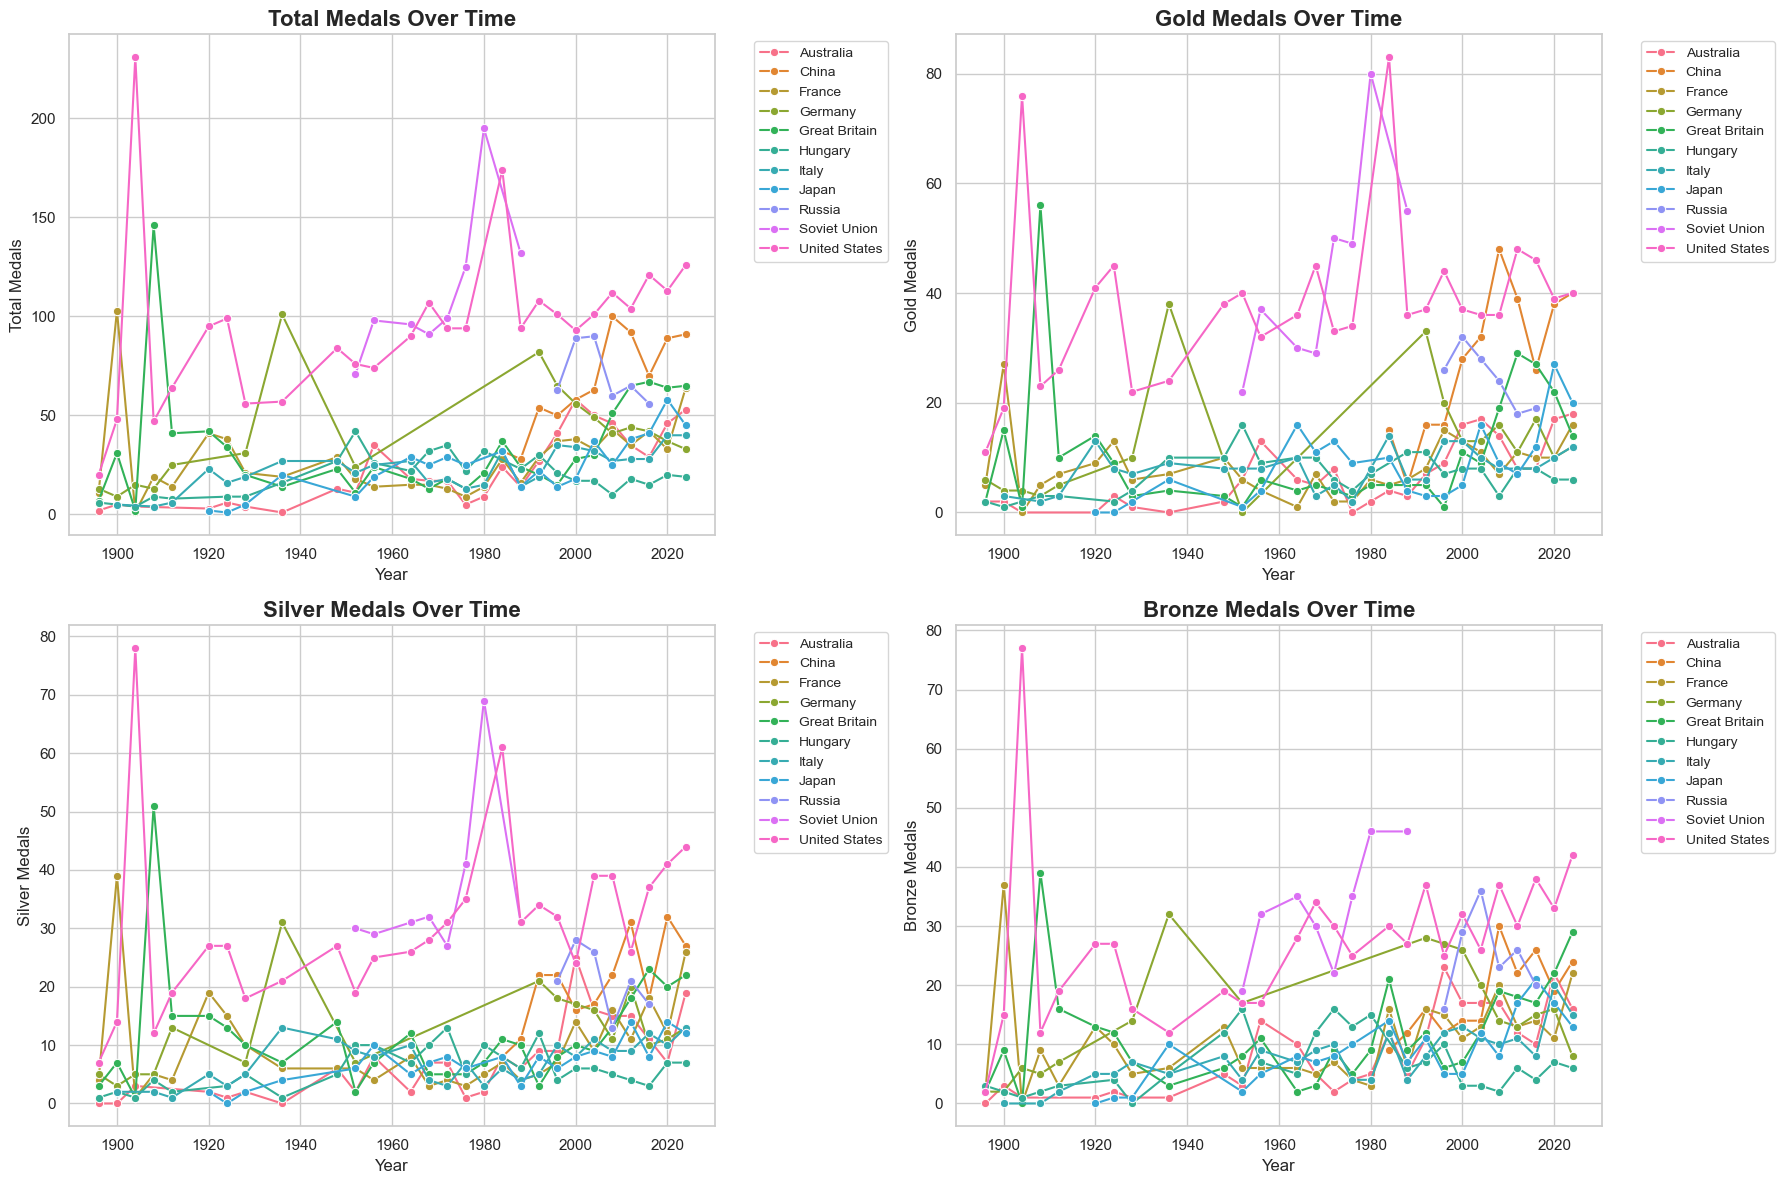

In [41]:
# Identify the Top 10 countries by all-time Total medals
# We use .tolist() so we can easily append another country to it
top_nocs = final_training_data.groupby('NOC')['Total'].sum().nlargest(10).index.tolist()

# Add Russia ('RUS') to the list making it 11 countries 
# (The if-statement ensures we don't add it twice if it naturally made the Top 10)
russia_code = 'Russia' 
if russia_code not in top_nocs:
    top_nocs.append(russia_code)

# Filter the dataframe to just these top countries + Russia
plot_data = final_training_data[final_training_data['NOC'].isin(top_nocs)]

# Set up a 2x2 grid for the 4 graphs
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Define the metrics and their respective graph titles
metrics = ['Total', 'Gold', 'Silver', 'Bronze']
titles = ['Total Medals Over Time', 'Gold Medals Over Time', 
          'Silver Medals Over Time', 'Bronze Medals Over Time']

# Loop through and create each plot
for i, metric in enumerate(metrics):
    sns.lineplot(
        data=plot_data, 
        x='Year', 
        y=metric, 
        hue='NOC', 
        marker='o',
        ax=axes[i]
    )
    
    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=12)
    axes[i].set_ylabel(f'{metric} Medals', fontsize=12)
    
    # Move the legend outside of the plot area so it doesn't cover the lines
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

We see here that The US, USSR, and China stand out among their peers in total medals. We also see them having the most medals in each medal event individually.

## Training

In [42]:
features = ['Total_Athletes', 'Total_Historical_Efficiency', 'is_Host', 'Male_Athletes', 'Female_Athletes', 'Unique_Sports', 'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals']
X = final_training_data[features]

# 2. Your target is now a DataFrame with TWO columns
targets = ['Total', 'Gold']
y = final_training_data[targets]

X_train, X_test, y_train_multi, y_test_multi = train_test_split(X, y, train_size = .7, random_state = 4025)

## Linear Pipeline

In [43]:
num = [
    'Total_Athletes', 
    'Total_Historical_Efficiency', 
    'Male_Athletes', 
    'Female_Athletes', 
    'Unique_Sports', 
    'Lag_1_Efficiency', 
    'Lag_2_Efficiency', 
    'Lag_3_Efficiency', 
    'Lag_1_Total_Medals', 
    'Lag_2_Total_Medals', 
    'Lag_3_Total_Medals'
]
cat = [
    'is_Host'
]
numeric_transformer = Pipeline(steps=[
    # Fills any blank numeric values with the median of that column
    ('imputer', SimpleImputer(strategy='median')), 
    # Standardizes numbers to have a mean of 0 and variance of 1
    ('scaler', StandardScaler()) 
])
categorical_transformer = Pipeline(steps=[
    # Fills any blank categorical values with the most common category
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Ensures categories are properly formatted for regression mathematics
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num),
    ('cat', categorical_transformer, cat)
])
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train_multi)
predictions = lr_pipeline.predict(X_test)

# 2. Extract the predictions into separate variables for clarity
# predictions[:, 0] grabs all rows for the first target ('Total')
# predictions[:, 1] grabs all rows for the second target ('Gold')
predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]

# 3. Extract the actual values for clarity
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 4. Calculate the Metrics!
# R2 Score: How much of the variance does the model explain? (Closer to 1.0 is better)
r2_lr_total = r2_score(actual_total, predicted_total)
r2_lr_gold = r2_score(actual_gold, predicted_gold)

# RMSE (Root Mean Squared Error): The average error, penalizing large misses heavily
rmse_lr_total = (root_mean_squared_error(actual_total, predicted_total))
rmse_lr_gold = (root_mean_squared_error(actual_gold, predicted_gold))

# MAE (Mean Absolute Error): The standard average error
mae_lr_total = mean_absolute_error(actual_total, predicted_total)
mae_lr_gold = mean_absolute_error(actual_gold, predicted_gold)

# 5. Print the professional summary
print("===== LINEAR REGRESSION PIPELINE RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_lr_total:.3f}")
print(f"RMSE:     {rmse_lr_total:.2f} medals")
print(f"MAE:      {mae_lr_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_lr_gold:.3f}")
print(f"RMSE:     {rmse_lr_gold:.2f} medals")
print(f"MAE:      {mae_lr_gold:.2f} medals")

===== LINEAR REGRESSION PIPELINE RESULTS =====

[TOTAL MEDALS]
R² Score: 0.745
RMSE:     11.05 medals
MAE:      5.90 medals

[GOLD MEDALS]
R² Score: 0.671
RMSE:     5.06 medals
MAE:      2.63 medals


We see here that the linear model has a high r2 but we see we are off by about 11 total medals and 5 gold medals yet our model occasionally fails with total because of the higher rmse.

## KNN Model

In [44]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# 2. Define the Grid of parameters to search
# - n_neighbors: How many similar countries should it compare to?
# - weights: 'uniform' (all neighbors equal) or 'distance' (closer neighbors count more)
param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'regressor__weights': ['uniform', 'distance']
}

# 3. Set up GridSearchCV
# cv=5 splits the training data into 5 folds to validate the parameters
grid_search = GridSearchCV(
    estimator=knn_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',  # Optimize for the best overall R² score
    n_jobs=-1      # Use all computer processors to speed up the search
)

grid_search.fit(X_train, y_train_multi)

# Extract the absolute best model it found
best_knn = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")

# 5. Make predictions on your X_test data using the winning model
predictions = best_knn.predict(X_test)

# Extract into separate arrays
predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 6. Calculate Metrics
r2_knn_total = r2_score(actual_total, predicted_total)
rmse_knn_total = (root_mean_squared_error(actual_total, predicted_total))
mae_knn_total = mean_absolute_error(actual_total, predicted_total)

r2_knn_gold = r2_score(actual_gold, predicted_gold)
rmse_knn_gold = (root_mean_squared_error(actual_gold, predicted_gold))
mae_knn_gold = mean_absolute_error(actual_gold, predicted_gold)

# 7. Print the beautiful summary!
print("\n===== KNN REGRESSION (BEST MODEL) RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_knn_total:.3f}")
print(f"RMSE:     {rmse_knn_total:.2f} medals")
print(f"MAE:      {mae_knn_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_knn_gold:.3f}")
print(f"RMSE:     {rmse_knn_gold:.2f} medals")
print(f"MAE:      {mae_knn_gold:.2f} medals")


✅ Best Parameters Found: {'regressor__n_neighbors': 5, 'regressor__weights': 'distance'}

===== KNN REGRESSION (BEST MODEL) RESULTS =====

[TOTAL MEDALS]
R² Score: 0.778
RMSE:     10.31 medals
MAE:      5.16 medals

[GOLD MEDALS]
R² Score: 0.720
RMSE:     4.67 medals
MAE:      2.26 medals


We see this model do a lot better. We see the total medals getting an r2 of .78 while it misses by 5 on average but we do occasionally fails and the gold misses by 2 medals. We don't want to use a cross validation because it will average the r2 of both total medals and gold medals.

## Random Forrest Pipeline

In [45]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor())
])

param_grid_rf = {
    'rf__max_features': [1, 2, 3],
    'rf__n_estimators' : [50,100,200],
    'rf__max_depth' : [None, 5,10,15]
}
rf_cv = KFold(n_splits = 5, shuffle = True, random_state= 4025)

rf_grid = GridSearchCV(
    estimator = rf_pipeline,
    param_grid= param_grid_rf,
    cv = rf_cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train_multi)

# 6. Make Predictions and Evaluate
best_rf = rf_grid.best_estimator_
predictions = best_rf.predict(X_test)

predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 7. Calculate and Print Metrics
r2_rf_total = r2_score(actual_total, predicted_total)
rmse_rf_total = (root_mean_squared_error(actual_total, predicted_total))
mae_rf_total = mean_absolute_error(actual_total, predicted_total)

r2_rf_gold = r2_score(actual_gold, predicted_gold)
rmse_rf_gold = (root_mean_squared_error(actual_gold, predicted_gold))
mae_rf_gold = mean_absolute_error(actual_gold, predicted_gold)

print("\n===== RANDOM FOREST REGRESSOR RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_rf_total:.3f}")
print(f"RMSE:     {rmse_rf_total:.2f} medals")
print(f"MAE:      {mae_rf_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_rf_gold:.3f}")
print(f"RMSE:     {rmse_rf_gold:.2f} medals")
print(f"MAE:      {mae_rf_gold:.2f} medals")




===== RANDOM FOREST REGRESSOR RESULTS =====

[TOTAL MEDALS]
R² Score: 0.827
RMSE:     9.10 medals
MAE:      4.65 medals

[GOLD MEDALS]
R² Score: 0.753
RMSE:     4.39 medals
MAE:      2.20 medals


This model improved a little bit getting us a higher r2 but we are missing by more on average than the KNN for total medals. Our Gold medals had a much better r2.

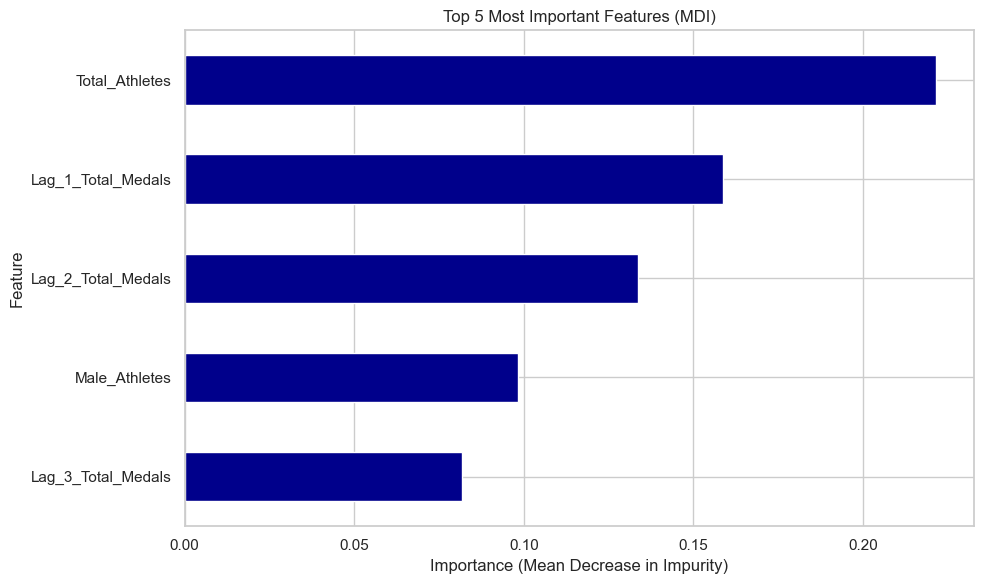

In [46]:
# 1. Extract the specific pieces from your best pipeline
# best_rf is your Pipeline object. We need the preprocessor and the actual Random Forest model.
preprocessor = best_rf.named_steps['preprocessor']
rf_model = best_rf.named_steps['rf']

# 2. Get the Feature Names out of the Preprocessor
# The preprocessor creates an array of names, but they often have prefixes like 'num__' or 'cat__'
raw_feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# Extract the feature importances from the model
importances = rf_model.feature_importances_

# Bind them to our clean feature names and sort them
importance_series = pd.Series(importances, index=clean_feature_names)
top_5_importances = importance_series.sort_values(ascending=False).head(5)

# Plot the bar chart
plt.figure(figsize=(10, 6))
# We sort ascending just for plotting so the biggest bar is on top
top_5_importances.sort_values(ascending=True).plot(kind='barh', color='darkblue')
plt.title('Top 5 Most Important Features (MDI)')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

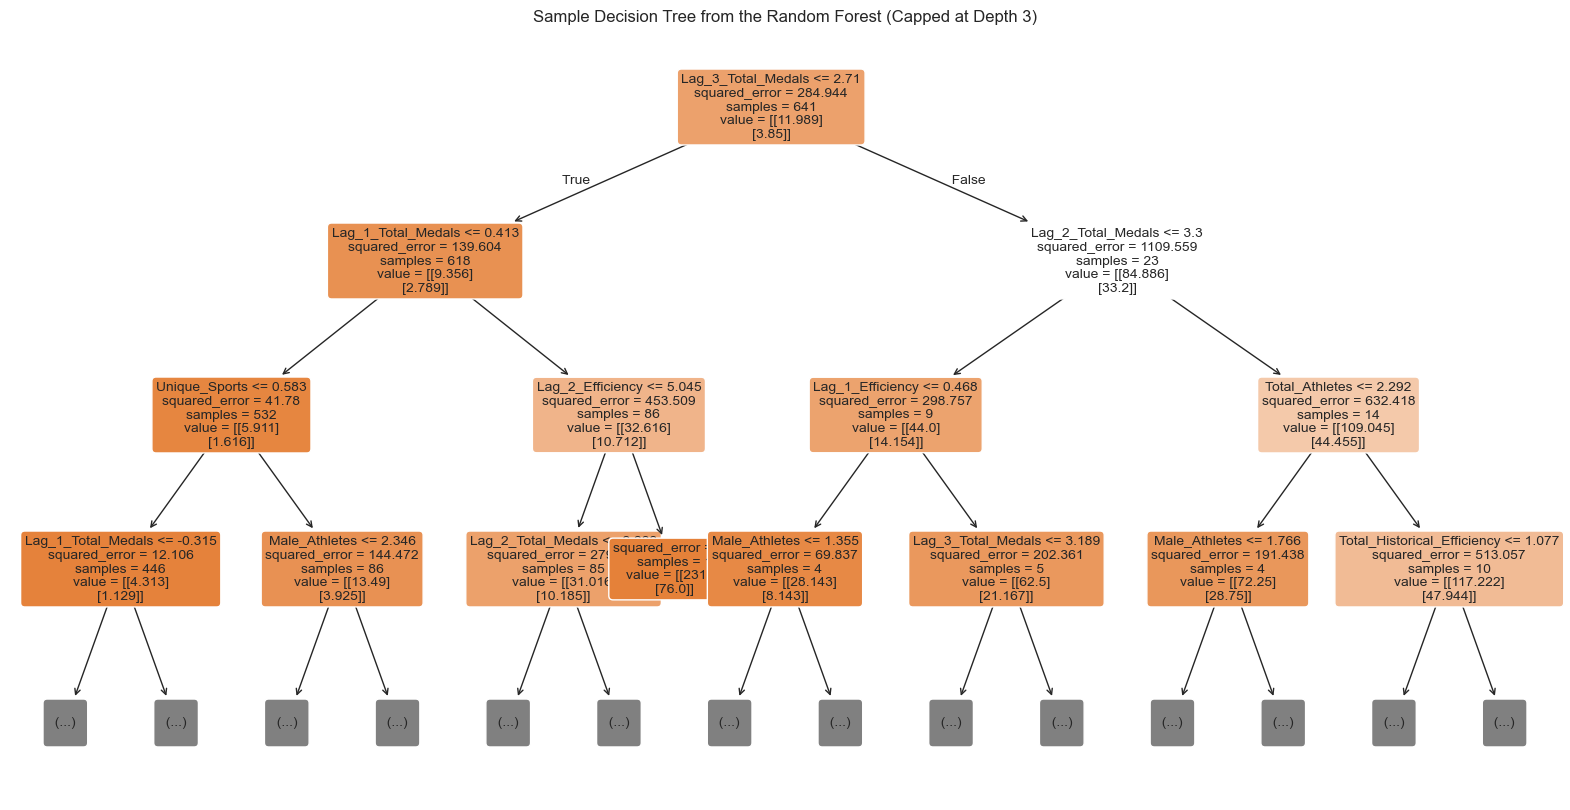

In [47]:
single_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    single_tree,
    feature_names=clean_feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3 
)
plt.title("Sample Decision Tree from the Random Forest (Capped at Depth 3)")
plt.show()

## HistGrad

In [48]:
num_transformer_no = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer_no = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessr_no_impute = ColumnTransformer([
    ('num', num_transformer_no, num),
    ('cat', cat_transformer_no, cat)
])
pipeline_impute = Pipeline([
    ('preprocessor', preprocessor),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
pipeline_noimpute = Pipeline([
    ('preprocessor', preprocessr_no_impute),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
models_to_test = {
    "HistGradient (WITH Imputer)": pipeline_impute,
    "HistGradient (NO Imputer)": pipeline_noimpute
}
param_grid = {
    'multi_regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
    'multi_regressor__estimator__max_iter': [100, 200, 300],
    'multi_regressor__estimator__max_depth': [None, 5, 10]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=4025)
results = {}

for name, pipeline in models_to_test.items():
    
    # Run GridSearch
    grid = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train_multi)
    
    # Predict
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    
    # Calculate TOTAL Medals Metrics (Column 0)
    r2_tot = r2_score(y_test_multi['Total'], preds[:, 0])
    rmse_tot = root_mean_squared_error(y_test_multi['Total'], preds[:, 0])
    mae_tot = mean_absolute_error(y_test_multi['Total'], preds[:, 0])

    # Calculate GOLD Medals Metrics (Column 1)
    r2_gld = r2_score(y_test_multi['Gold'], preds[:, 1])
    rmse_gld = root_mean_squared_error(y_test_multi['Gold'], preds[:, 1])
    mae_gld = mean_absolute_error(y_test_multi['Gold'], preds[:, 1])
    
    # Save ALL results
    results[name] = {
        'Total_R2': r2_tot, 
        'Total_RMSE': rmse_tot, 
        'Total_MAE': mae_tot, 
        'Gold_R2': r2_gld,
        'Gold_RMSE': rmse_gld,
        'Gold_MAE': mae_gld,
        'BestParams': grid.best_params_
    }

print("\n===== HIST-GRADIENT SHOWDOWN =====")
for name, metrics in results.items():
    print(f"\n🥇 {name}:")
    print(f"  [TOTAL] R²: {metrics['Total_R2']:.3f} | RMSE: {metrics['Total_RMSE']:.2f} | MAE: {metrics['Total_MAE']:.2f}")
    print(f"  [GOLD]  R²: {metrics['Gold_R2']:.3f} | RMSE: {metrics['Gold_RMSE']:.2f} | MAE: {metrics['Gold_MAE']:.2f}")

print("\n🏆 Winner for Total R²: ", max(results, key=lambda k: results[k]['Total_R2']))
print("🏆 Winner for Gold R²:  ", max(results, key=lambda k: results[k]['Gold_R2']))


===== HIST-GRADIENT SHOWDOWN =====

🥇 HistGradient (WITH Imputer):
  [TOTAL] R²: 0.802 | RMSE: 9.72 | MAE: 5.05
  [GOLD]  R²: 0.714 | RMSE: 4.72 | MAE: 2.38

🥇 HistGradient (NO Imputer):
  [TOTAL] R²: 0.802 | RMSE: 9.72 | MAE: 5.05
  [GOLD]  R²: 0.714 | RMSE: 4.72 | MAE: 2.38

🏆 Winner for Total R²:  HistGradient (WITH Imputer)
🏆 Winner for Gold R²:   HistGradient (WITH Imputer)


Now lets compare the models

In [49]:
hist_name = "HistGradient (WITH Imputer)"
hist_r2_tot = results[hist_name]['Total_R2']
hist_rmse_tot = results[hist_name]['Total_RMSE']
hist_mae_tot = results[hist_name]['Total_MAE']
hist_r2_gold = results[hist_name]['Gold_R2']
hist_rmse_gold = results[hist_name]['Gold_RMSE']
hist_mae_gold = results[hist_name]['Gold_MAE']

# 2. Build the Master Dictionary
summary_data = {
    "Model": [
        "Linear Regression", 
        "KNN Regressor", 
        "Random Forest", 
        "HistGradient Boosting"
    ],
    
    # --- TOTAL MEDALS METRICS ---
    "Total_R²": [r2_lr_total, r2_knn_total, r2_rf_total, hist_r2_tot],
    "Total_RMSE": [rmse_lr_total, rmse_knn_total, rmse_rf_total, hist_rmse_tot],
    "Total_MAE": [mae_lr_total, mae_knn_total, mae_rf_total, hist_mae_tot],
    
    # --- GOLD MEDALS METRICS ---
    "Gold_R²": [r2_lr_gold, r2_knn_gold, r2_rf_gold, hist_r2_gold],
    "Gold_RMSE": [rmse_lr_gold, rmse_knn_gold, rmse_rf_gold, hist_rmse_gold],
    "Gold_MAE": [mae_lr_gold, mae_knn_gold, mae_rf_gold, hist_mae_gold]
}

# 3. Convert to a DataFrame
scoreboard_df = pd.DataFrame(summary_data)

# 4. FIX: Use .apply() instead of .applymap() or .map() 
# .apply() is the safest and most robust way to round entire columns in modern Pandas
numeric_cols = ["Total_R²", "Total_RMSE", "Total_MAE"]
scoreboard_df[numeric_cols] = scoreboard_df[numeric_cols].apply(lambda x: round(x, 3))

# 5. Display the final table!
print("\n" + "="*70)
print("🏆 OLYMPIC MODEL SHOWDOWN - FINAL SCOREBOARD 🏆")
print("="*70)
print(scoreboard_df.to_string(index=False))


🏆 OLYMPIC MODEL SHOWDOWN - FINAL SCOREBOARD 🏆
                Model  Total_R²  Total_RMSE  Total_MAE  Gold_R²  Gold_RMSE  Gold_MAE
    Linear Regression     0.745      11.053      5.895 0.671339   5.063189  2.628903
        KNN Regressor     0.778      10.307      5.162 0.720210   4.671610  2.257640
        Random Forest     0.827       9.104      4.648 0.752565   4.393198  2.196126
HistGradient Boosting     0.802       9.724      5.053 0.714325   4.720481  2.382729


We see that HistGradient Boosting gives us the best R2 with the lowest on average missing for total medals and gold medals. We will now predict the 2028!

## 2028

In [50]:

# 1. Isolate the 2024 data - this is our "launch pad" for 2028
data_2024 = final_training_data[final_training_data['Year'] == 2024].copy()

# Create the base 2028 DataFrame
data_2028 = pd.DataFrame()
data_2028['NOC'] = data_2024['NOC'].values
data_2028['Year'] = 2028

# 2. USA gets the Host advantage
data_2028['is_Host'] = (data_2028['NOC'] == 'USA').astype(int)

# 3. Carry over the Demographic & Sport Data (Using 2024 as the proxy for 2028)
data_2028['Total_Athletes'] = data_2024['Total_Athletes'].values
data_2028['Male_Athletes'] = data_2024['Male_Athletes'].values
data_2028['Female_Athletes'] = data_2024['Female_Athletes'].values
data_2028['Unique_Sports'] = data_2024['Unique_Sports'].values

# 4. Shift the Medal Lags Forward
# 2028's Lag 1 is the ACTUAL medals won in 2024
data_2028['Lag_1_Total_Medals'] = data_2024['Total'].values
# 2028's Lag 2 is 2024's Lag 1 (which was 2020), and so on
data_2028['Lag_2_Total_Medals'] = data_2024['Lag_1_Total_Medals'].values
data_2028['Lag_3_Total_Medals'] = data_2024['Lag_2_Total_Medals'].values

# 5. Shift the Efficiency Lags Forward
# Calculate 2024's actual efficiency to use as 2028's Lag 1
actual_2024_efficiency = np.where(
    data_2024['Total_Athletes'] > 0, 
    data_2024['Total'] / data_2024['Total_Athletes'], 
    0
)
data_2028['Lag_1_Efficiency'] = actual_2024_efficiency
data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Efficiency'].values
data_2028['Lag_3_Efficiency'] = data_2024['Lag_2_Efficiency'].values

# Carry over the cumulative historical efficiency
data_2028['Total_Historical_Efficiency'] = data_2024['Total_Historical_Efficiency'].values

# 6. Ensure the features match EXACTLY the order the model was trained on
features = [
    'Total_Athletes', 'Total_Historical_Efficiency', 'is_Host', 
    'Male_Athletes', 'Female_Athletes', 'Unique_Sports', 
    'Lag_1_Efficiency', 'Lag_2_Efficiency', 'Lag_3_Efficiency', 
    'Lag_1_Total_Medals', 'Lag_2_Total_Medals', 'Lag_3_Total_Medals'
]
X_2028 = data_2028[features]

# 7. Make Predictions using your Best Random Forest Model!
# Note: best_rf is already fitted from your GridSearchCV step
predictions_2028 = best_rf.predict(X_2028)

# Extract Total and Gold, and round them to whole numbers
data_2028['Predicted_Total'] = np.round(predictions_2028[:, 0]).astype(int)
data_2028['Predicted_Gold'] = np.round(predictions_2028[:, 1]).astype(int)

# Random Forests rarely predict negative numbers, but clipping is a good safety net
data_2028['Predicted_Total'] = data_2028['Predicted_Total'].clip(lower=0)
data_2028['Predicted_Gold'] = data_2028['Predicted_Gold'].clip(lower=0)

# Sort by Most Gold Medals (Standard Olympic Ranking), then Most Total Medals
leaderboard_2028 = data_2028.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

# Print the Results!
print("\n" + "="*50)
print("🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS (RANDOM FOREST) 🇺🇸")
print("="*50)
print(leaderboard_2028[['NOC', 'Predicted_Gold', 'Predicted_Total']].head(20).to_string(index=False))


🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS (RANDOM FOREST) 🇺🇸
          NOC  Predicted_Gold  Predicted_Total
United States              43              121
        China              39               96
       France              24               65
Great Britain              22               67
    Australia              19               54
        Japan              15               46
      Germany              13               39
        Italy              12               39
  Netherlands              11               36
       Canada               9               29
  New Zealand               8               21
      Hungary               7               20
        Spain               6               23
  South Korea               6               19
       Brazil               5               21
      Ukraine               4               14
       Poland               3               13
      Belgium               3               11
  Switzerland               3           

Now lets graph them to get a closer look

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Prepare data for plotting (Top 15 Countries)
plot_data = leaderboard_2028.head(15)

# --- CHART 1: TOTAL MEDALS ---
plt.tight_layout()
ax1 = sns.barplot(
    x='Predicted_Total', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Total', ascending=False),
    palette='viridis'
)
plt.title('Top 15 Projected Nations: Total Medals (LA 2028)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Total Medals')
plt.ylabel('Country (NOC)')

# Add labels to the ends of the bars
for i in ax1.containers:
    ax1.bar_label(i, padding=3)

plt.savefig('2028_total_medals_projection.png', bbox_inches='tight', dpi=300)
plt.close() # Close to start a fresh plot

# --- CHART 2: GOLD MEDALS ---
plt.tight_layout()
ax2 = sns.barplot(
    x='Predicted_Gold', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Gold', ascending=False),
    palette='magma'
)
plt.title('Top 15 Projected Nations: Gold Medals (LA 2028)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Gold Medals')
plt.ylabel('Country (NOC)')

# Add labels to the ends of the bars
for i in ax2.containers:
    ax2.bar_label(i, padding=3)

plt.savefig('2028_gold_medals_projection.png', bbox_inches='tight', dpi=300)
plt.close()

print("Graphs have been saved as '2028_total_medals_projection.png' and '2028_gold_medals_projection.png'")

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_6336\1908376634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_6336\1908376634.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Graphs have been saved as '2028_total_medals_projection.png' and '2028_gold_medals_projection.png'


## Events

Now I want to build a model which will predict each sport

In [74]:

# 1. Base Framework: Athletes & Demographics per sport
# Pivot 'Sex' to get Male and Female counts per sport
sex_counts = athletes.groupby(['Year', 'Team', 'Sport', 'Sex']).size().unstack(fill_value=0).reset_index()

# Safety net: ensure columns exist even if data is weirdly shaped
if 'M' not in sex_counts.columns: sex_counts['M'] = 0
if 'F' not in sex_counts.columns: sex_counts['F'] = 0

sex_counts = sex_counts.rename(columns={'M': 'Male_Athletes', 'F': 'Female_Athletes'})
sex_counts['Sport_Athletes'] = sex_counts['Male_Athletes'] + sex_counts['Female_Athletes']

# Rename to match our pipeline
sport_athletes = sex_counts

# 2. Target Variables: Get all medal types simultaneously using .unstack()
valid_medals = athletes.dropna(subset=['Medal']).copy()
valid_medals = valid_medals[valid_medals['Medal'] != 'No medal']

# Group by Medal type and pivot
medal_breakdown = valid_medals.groupby(['Year', 'Team', 'Sport', 'Medal']).size().unstack(fill_value=0).reset_index()

# Ensure the columns exist
for col in ['Gold', 'Silver', 'Bronze']:
    if col not in medal_breakdown.columns:
        medal_breakdown[col] = 0

medal_breakdown = medal_breakdown.rename(columns={
    'Gold': 'Sport_Gold_Medals',
    'Silver': 'Sport_Silver_Medals',
    'Bronze': 'Sport_Bronze_Medals'
})

medal_breakdown['Sport_Total_Medals'] = (
    medal_breakdown['Sport_Gold_Medals'] + 
    medal_breakdown['Sport_Silver_Medals'] + 
    medal_breakdown['Sport_Bronze_Medals']
)

# 3. Merge into a single master table
df_sport = sport_athletes.merge(medal_breakdown, on=['Year', 'Team', 'Sport'], how='left')

# Fill NaNs with 0 (competed, but won 0 medals)
medal_cols = ['Sport_Total_Medals', 'Sport_Gold_Medals', 'Sport_Silver_Medals', 'Sport_Bronze_Medals']
df_sport[medal_cols] = df_sport[medal_cols].fillna(0)

# 4. Feature Engineering: The Lags & Efficiencies
# CRITICAL: We MUST sort by Team -> Sport -> Year
df_sport = df_sport.sort_values(by=['Team', 'Sport', 'Year'])

# Standard Lags
df_sport['Lag_1_Sport_Medals'] = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].shift(1)
df_sport['Lag_2_Sport_Medals'] = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].shift(2)

# Current Efficiency (Temporary, used to create the lag)
df_sport['Current_Sport_Efficiency'] = np.where(
    df_sport['Sport_Athletes'] > 0,
    df_sport['Sport_Total_Medals'] / df_sport['Sport_Athletes'],
    0
)
df_sport['Lag_1_Sport_Efficiency'] = df_sport.groupby(['Team', 'Sport'])['Current_Sport_Efficiency'].shift(1)
df_sport['Lag_2_Sport_Efficiency'] = df_sport.groupby(['Team', 'Sport'])['Current_Sport_Efficiency'].shift(2)


# NEW: Total Historical Efficiency
# Calculate cumulative sums, and shift them down 1 to prevent data leakage
cum_medals = df_sport.groupby(['Team', 'Sport'])['Sport_Total_Medals'].cumsum().shift(1)
cum_athletes = df_sport.groupby(['Team', 'Sport'])['Sport_Athletes'].cumsum().shift(1)

df_sport['Total_Historical_Efficiency'] = np.where(
    cum_athletes > 0,
    cum_medals / cum_athletes,
    0
)

# 5. Final Cleanup
cols_to_fill = [
    'Lag_1_Sport_Medals', 'Lag_2_Sport_Medals', 
    'Lag_1_Sport_Efficiency', 'Lag_2_Sport_Efficiency', 'Total_Historical_Efficiency'
]
df_sport[cols_to_fill] = df_sport[cols_to_fill].fillna(0)

# Drop the leaky variable
df_sport = df_sport.drop(columns=['Current_Sport_Efficiency'])

# 6. Bring in the Host Advantage
df_sport = df_sport.merge(hosts, on='Year', how='left')
df_sport['is_Host'] = df_sport.apply(lambda row: 1 if pd.notna(row['Host']) and str(row['Team']) in str(row['Host']) else 0, axis=1)
df_sport = df_sport.drop(columns=['Host'])

df_sport.head(15)

,Year,Team,Sport,Female_Athletes,Male_Athletes,Sport_Athletes,Sport_Bronze_Medals,Sport_Gold_Medals,Sport_Silver_Medals,Sport_Total_Medals,Lag_1_Sport_Medals,Lag_2_Sport_Medals,Lag_1_Sport_Efficiency,Lag_2_Sport_Efficiency,Total_Historical_Efficiency,is_Host
0,1952,30. Februar,Sailing,0,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
1,1900,A North American Team,Polo,0,4,4,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.000000,0
2,2024,AIN,Canoe Sprint,2,4,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0
3,2024,AIN,Cycling Road,5,2,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
4,2024,AIN,Rowing,1,1,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0
5,2024,AIN,Shooting,2,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0
6,2024,AIN,Swimming,4,3,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
7,2024,AIN,Taekwondo,0,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
8,2024,AIN,Tennis,8,6,14,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.000000,0
9,2024,AIN,Trampoline Gymnastics,2,1,3,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.142857,0


In [75]:
features = ['Sport', 'Team','Total_Historical_Efficiency', 'is_Host', 'Male_Athletes', 'Female_Athletes',  'Lag_1_Sport_Efficiency', 'Lag_2_Sport_Efficiency',  'Lag_1_Sport_Medals', 'Lag_2_Sport_Medals']
X = df_sport[features]

targets = ['Sport_Bronze_Medals', 'Sport_Silver_Medals', 'Sport_Gold_Medals', 'Sport_Total_Medals']
y = df_sport[targets]

X_train_sport, X_test_sport, y_train_multi_sport, y_test_multi_sport = train_test_split(X, y, train_size = .7, random_state = 4025)

In [76]:
num = [
    'Total_Historical_Efficiency', 
    'Male_Athletes', 
    'Female_Athletes', 
    'Lag_1_Sport_Efficiency', 
    'Lag_2_Sport_Efficiency', 
    'Lag_1_Sport_Medals', 
    'Lag_2_Sport_Medals'
]

cat = [
    'Sport', 
    'Team', 
    'is_Host'
]

## Lr Pipeline

In [83]:
numeric_transformer = Pipeline(steps=[
    # Fills any blank numeric values with the median of that column
    ('imputer', SimpleImputer(strategy='median')), 
    # Standardizes numbers to have a mean of 0 and variance of 1
    ('scaler', StandardScaler()) 
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num),
    ('cat', categorical_transformer, cat)
])
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit and Predict using your NEW sport-level splits
lr_pipeline.fit(X_train_sport, y_train_multi_sport)
predictions = lr_pipeline.predict(X_test_sport)

# 2. Extract the predictions using the NEW index order
# Order of targets: [Bronze (0), Silver (1), Gold (2), Total (3)]
predicted_bronze = predictions[:, 0]
predicted_silver = predictions[:, 1]
predicted_gold   = predictions[:, 2]
predicted_total  = predictions[:, 3]

# 3. Extract the actual values using the NEW column names
actual_bronze = y_test_multi_sport['Sport_Bronze_Medals']
actual_silver = y_test_multi_sport['Sport_Silver_Medals']
actual_gold   = y_test_multi_sport['Sport_Gold_Medals']
actual_total  = y_test_multi_sport['Sport_Total_Medals']

# 4. Calculate the Metrics!
# Total Medals
r2_lr_total = r2_score(actual_total, predicted_total)
rmse_lr_total = root_mean_squared_error(actual_total, predicted_total)
mae_lr_total = mean_absolute_error(actual_total, predicted_total)

# --- Gold Medals ---
r2_lr_gold = r2_score(actual_gold, predicted_gold)
rmse_lr_gold = root_mean_squared_error(actual_gold, predicted_gold)
mae_lr_gold = mean_absolute_error(actual_gold, predicted_gold)

# --- Silver Medals ---
r2_lr_silver = r2_score(actual_silver, predicted_silver)
rmse_lr_silver = root_mean_squared_error(actual_silver, predicted_silver)
mae_lr_silver = mean_absolute_error(actual_silver, predicted_silver)

# --- Bronze Medals ---
r2_lr_bronze = r2_score(actual_bronze, predicted_bronze)
rmse_lr_bronze = root_mean_squared_error(actual_bronze, predicted_bronze)
mae_lr_bronze = mean_absolute_error(actual_bronze, predicted_bronze)


# 5. Print the professional summary
print("===== LINEAR REGRESSION PIPELINE RESULTS (SPORT LEVEL) =====")

print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_lr_total:.3f}")
print(f"RMSE:     {rmse_lr_total:.2f} medals")
print(f"MAE:      {mae_lr_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_lr_gold:.3f}")
print(f"RMSE:     {rmse_lr_gold:.2f} medals")
print(f"MAE:      {mae_lr_gold:.2f} medals")

print("\n[SILVER MEDALS]")
print(f"R² Score: {r2_lr_silver:.3f}")
print(f"RMSE:     {rmse_lr_silver:.2f} medals")
print(f"MAE:      {mae_lr_silver:.2f} medals")

print("\n[BRONZE MEDALS]")
print(f"R² Score: {r2_lr_bronze:.3f}")
print(f"RMSE:     {rmse_lr_bronze:.2f} medals")
print(f"MAE:      {mae_lr_bronze:.2f} medals")

===== LINEAR REGRESSION PIPELINE RESULTS (SPORT LEVEL) =====

[TOTAL MEDALS]
R² Score: 0.566
RMSE:     2.82 medals
MAE:      1.33 medals

[GOLD MEDALS]
R² Score: 0.335
RMSE:     1.86 medals
MAE:      0.66 medals

[SILVER MEDALS]
R² Score: 0.231
RMSE:     1.67 medals
MAE:      0.64 medals

[BRONZE MEDALS]
R² Score: 0.214
RMSE:     1.69 medals
MAE:      0.67 medals


## KNN

In [84]:
# 1. Define the Pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# 2. Define the Grid of parameters to search
# - n_neighbors: How many similar countries should it compare to?
# - weights: 'uniform' (all neighbors equal) or 'distance' (closer neighbors count more)
param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'regressor__weights': ['uniform', 'distance']
}

# 3. Set up GridSearchCV
# cv=5 splits the training data into 5 folds to validate the parameters
grid_search = GridSearchCV(
    estimator=knn_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',  # Optimize for the best overall R² score
    n_jobs=-1      # Use all computer processors to speed up the search
)

# 4. Fit using the NEW sport-level training data
grid_search.fit(X_train_sport, y_train_multi_sport)

# Extract the absolute best model it found
best_knn = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")

# 5. Make predictions on your NEW sport-level test data
predictions = best_knn.predict(X_test_sport)

# Extract into separate arrays using the NEW index order
# Order: [Bronze (0), Silver (1), Gold (2), Total (3)]
predicted_bronze = predictions[:, 0]
predicted_silver = predictions[:, 1]
predicted_gold   = predictions[:, 2]
predicted_total  = predictions[:, 3]

# Extract actuals using the NEW column names
actual_bronze = y_test_multi_sport['Sport_Bronze_Medals']
actual_silver = y_test_multi_sport['Sport_Silver_Medals']
actual_gold   = y_test_multi_sport['Sport_Gold_Medals']
actual_total  = y_test_multi_sport['Sport_Total_Medals']

# 6. Calculate Metrics for ALL four targets
# --- Total Medals ---
r2_knn_total = r2_score(actual_total, predicted_total)
rmse_knn_total = root_mean_squared_error(actual_total, predicted_total)
mae_knn_total = mean_absolute_error(actual_total, predicted_total)

# --- Gold Medals ---
r2_knn_gold = r2_score(actual_gold, predicted_gold)
rmse_knn_gold = root_mean_squared_error(actual_gold, predicted_gold)
mae_knn_gold = mean_absolute_error(actual_gold, predicted_gold)

# --- Silver Medals ---
r2_knn_silver = r2_score(actual_silver, predicted_silver)
rmse_knn_silver = root_mean_squared_error(actual_silver, predicted_silver)
mae_knn_silver = mean_absolute_error(actual_silver, predicted_silver)

# --- Bronze Medals ---
r2_knn_bronze = r2_score(actual_bronze, predicted_bronze)
rmse_knn_bronze = root_mean_squared_error(actual_bronze, predicted_bronze)
mae_knn_bronze = mean_absolute_error(actual_bronze, predicted_bronze)

# 7. Print the complete summary!
print("\n===== KNN REGRESSION (BEST MODEL) RESULTS =====")

print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_knn_total:.3f}")
print(f"RMSE:     {rmse_knn_total:.2f} medals")
print(f"MAE:      {mae_knn_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_knn_gold:.3f}")
print(f"RMSE:     {rmse_knn_gold:.2f} medals")
print(f"MAE:      {mae_knn_gold:.2f} medals")

print("\n[SILVER MEDALS]")
print(f"R² Score: {r2_knn_silver:.3f}")
print(f"RMSE:     {rmse_knn_silver:.2f} medals")
print(f"MAE:      {mae_knn_silver:.2f} medals")

print("\n[BRONZE MEDALS]")
print(f"R² Score: {r2_knn_bronze:.3f}")
print(f"RMSE:     {rmse_knn_bronze:.2f} medals")
print(f"MAE:      {mae_knn_bronze:.2f} medals")


✅ Best Parameters Found: {'regressor__n_neighbors': 20, 'regressor__weights': 'uniform'}

===== KNN REGRESSION (BEST MODEL) RESULTS =====

[TOTAL MEDALS]
R² Score: 0.569
RMSE:     2.81 medals
MAE:      1.18 medals

[GOLD MEDALS]
R² Score: 0.374
RMSE:     1.81 medals
MAE:      0.53 medals

[SILVER MEDALS]
R² Score: 0.208
RMSE:     1.70 medals
MAE:      0.57 medals

[BRONZE MEDALS]
R² Score: 0.212
RMSE:     1.69 medals
MAE:      0.59 medals


## Random Forrest

In [79]:
# 1. Define the Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # Added random_state here to ensure your results stay perfectly consistent across runs
    ('rf', RandomForestRegressor(random_state=4025)) 
])

# 2. Define the Grid of parameters to search
param_grid_rf = {
    'rf__max_features': [1, 2, 3],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10, 15]
}
rf_cv = KFold(n_splits=5, shuffle=True, random_state=4025)

# 3. Set up GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=rf_cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)

# 4. Fit using the NEW sport-level training data
rf_grid.fit(X_train_sport, y_train_multi_sport)

# 5. Make Predictions and Evaluate
best_rf = rf_grid.best_estimator_
print(f"\n✅ Best Parameters Found: {rf_grid.best_params_}")

predictions = best_rf.predict(X_test_sport)

# Extract into separate arrays using the NEW index order
# Order: [Bronze (0), Silver (1), Gold (2), Total (3)]
predicted_bronze = predictions[:, 0]
predicted_silver = predictions[:, 1]
predicted_gold   = predictions[:, 2]
predicted_total  = predictions[:, 3]

# Extract actuals using the NEW column names
actual_bronze = y_test_multi_sport['Sport_Bronze_Medals']
actual_silver = y_test_multi_sport['Sport_Silver_Medals']
actual_gold   = y_test_multi_sport['Sport_Gold_Medals']
actual_total  = y_test_multi_sport['Sport_Total_Medals']

# 6. Calculate Metrics for ALL four targets
# --- Total Medals ---
r2_rf_total = r2_score(actual_total, predicted_total)
rmse_rf_total = root_mean_squared_error(actual_total, predicted_total)
mae_rf_total = mean_absolute_error(actual_total, predicted_total)

# --- Gold Medals ---
r2_rf_gold = r2_score(actual_gold, predicted_gold)
rmse_rf_gold = root_mean_squared_error(actual_gold, predicted_gold)
mae_rf_gold = mean_absolute_error(actual_gold, predicted_gold)

# --- Silver Medals ---
r2_rf_silver = r2_score(actual_silver, predicted_silver)
rmse_rf_silver = root_mean_squared_error(actual_silver, predicted_silver)
mae_rf_silver = mean_absolute_error(actual_silver, predicted_silver)

# --- Bronze Medals ---
r2_rf_bronze = r2_score(actual_bronze, predicted_bronze)
rmse_rf_bronze = root_mean_squared_error(actual_bronze, predicted_bronze)
mae_rf_bronze = mean_absolute_error(actual_bronze, predicted_bronze)

# 7. Print the complete summary!
print("\n===== RANDOM FOREST REGRESSOR (BEST MODEL) RESULTS =====")

print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_rf_total:.3f}")
print(f"RMSE:     {rmse_rf_total:.2f} medals")
print(f"MAE:      {mae_rf_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_rf_gold:.3f}")
print(f"RMSE:     {rmse_rf_gold:.2f} medals")
print(f"MAE:      {mae_rf_gold:.2f} medals")

print("\n[SILVER MEDALS]")
print(f"R² Score: {r2_rf_silver:.3f}")
print(f"RMSE:     {rmse_rf_silver:.2f} medals")
print(f"MAE:      {mae_rf_silver:.2f} medals")

print("\n[BRONZE MEDALS]")
print(f"R² Score: {r2_rf_bronze:.3f}")
print(f"RMSE:     {rmse_rf_bronze:.2f} medals")
print(f"MAE:      {mae_rf_bronze:.2f} medals")


✅ Best Parameters Found: {'rf__max_depth': None, 'rf__max_features': 3, 'rf__n_estimators': 200}

===== RANDOM FOREST REGRESSOR (BEST MODEL) RESULTS =====

[TOTAL MEDALS]
R² Score: 0.585
RMSE:     2.76 medals
MAE:      1.16 medals

[GOLD MEDALS]
R² Score: 0.392
RMSE:     1.78 medals
MAE:      0.54 medals

[SILVER MEDALS]
R² Score: 0.190
RMSE:     1.72 medals
MAE:      0.58 medals

[BRONZE MEDALS]
R² Score: 0.198
RMSE:     1.70 medals
MAE:      0.60 medals


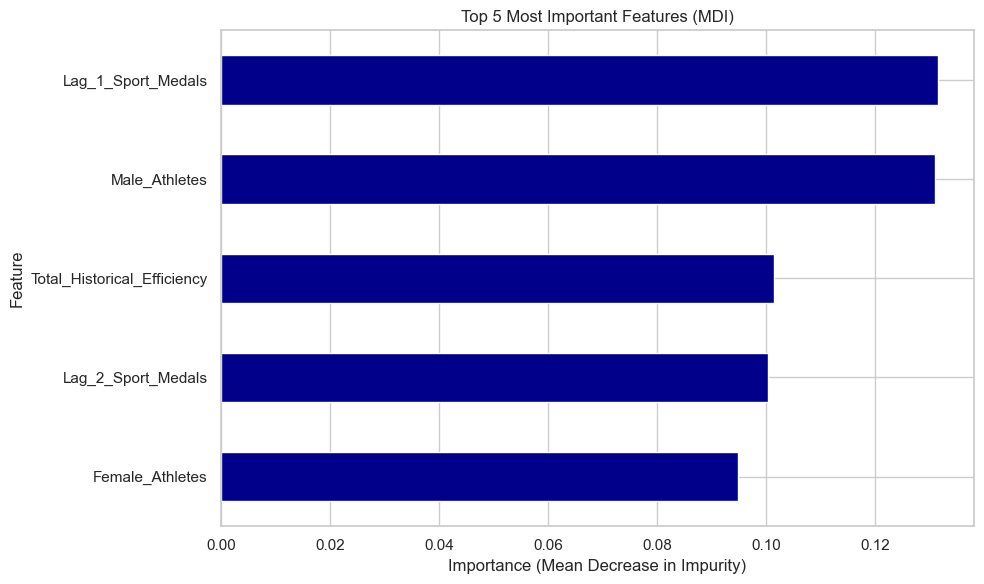

In [85]:
# 1. Extract the specific pieces from your best pipeline
# best_rf is your Pipeline object. We need the preprocessor and the actual Random Forest model.
preprocessor = best_rf.named_steps['preprocessor']
rf_model = best_rf.named_steps['rf']

# 2. Get the Feature Names out of the Preprocessor
# The preprocessor creates an array of names, but they often have prefixes like 'num__' or 'cat__'
raw_feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# Extract the feature importances from the model
importances = rf_model.feature_importances_

# Bind them to our clean feature names and sort them
importance_series = pd.Series(importances, index=clean_feature_names)
top_5_importances = importance_series.sort_values(ascending=False).head(5)

# Plot the bar chart
plt.figure(figsize=(10, 6))
# We sort ascending just for plotting so the biggest bar is on top
top_5_importances.sort_values(ascending=True).plot(kind='barh', color='darkblue')
plt.title('Top 5 Most Important Features (MDI)')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Hist Grad Boost

In [87]:
num_transformer_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer_impute = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])
preprocessor = ColumnTransformer([
    ('num', num_transformer_impute, num),
    ('cat', cat_transformer_impute, cat)
])

# Pipeline B: NO Imputer
num_transformer_no = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer_no = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessr_no_impute = ColumnTransformer([
    ('num', num_transformer_no, num),
    ('cat', cat_transformer_no, cat)
])
pipeline_impute = Pipeline([
    ('preprocessor', preprocessor), # Assumes preprocessor is defined above
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
pipeline_noimpute = Pipeline([
    ('preprocessor', preprocessr_no_impute),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])

models_to_test = {
    "HistGradient (WITH Imputer)": pipeline_impute,
    "HistGradient (NO Imputer)": pipeline_noimpute
}

param_grid = {
    'multi_regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
    'multi_regressor__estimator__max_iter': [100, 200, 300],
    'multi_regressor__estimator__max_depth': [None, 5, 10]
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=4025)
results = {}

for name, pipeline in models_to_test.items():
    
    # Run GridSearch using NEW sport-level training data
    grid = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='r2', n_jobs=-1)
    grid.fit(X_train_sport, y_train_multi_sport)
    
    # Predict using NEW sport-level test data
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test_sport)
    
    # Order of targets: [Bronze (0), Silver (1), Gold (2), Total (3)]
    
    # Calculate TOTAL Medals Metrics (Column 3)
    r2_tot = r2_score(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])
    rmse_tot = root_mean_squared_error(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])
    mae_tot = mean_absolute_error(y_test_multi_sport['Sport_Total_Medals'], preds[:, 3])

    # Calculate GOLD Medals Metrics (Column 2)
    r2_gld = r2_score(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])
    rmse_gld = root_mean_squared_error(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])
    mae_gld = mean_absolute_error(y_test_multi_sport['Sport_Gold_Medals'], preds[:, 2])

    # Calculate SILVER Medals Metrics (Column 1)
    r2_slv = r2_score(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])
    rmse_slv = root_mean_squared_error(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])
    mae_slv = mean_absolute_error(y_test_multi_sport['Sport_Silver_Medals'], preds[:, 1])

    # Calculate BRONZE Medals Metrics (Column 0)
    r2_brz = r2_score(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    rmse_brz = root_mean_squared_error(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    mae_brz = mean_absolute_error(y_test_multi_sport['Sport_Bronze_Medals'], preds[:, 0])
    
    # Save ALL results
    results[name] = {
        'Total_R2': r2_tot, 'Total_RMSE': rmse_tot, 'Total_MAE': mae_tot,
        'Gold_R2': r2_gld,  'Gold_RMSE': rmse_gld,  'Gold_MAE': mae_gld,
        'Silver_R2': r2_slv,'Silver_RMSE': rmse_slv,'Silver_MAE': mae_slv,
        'Bronze_R2': r2_brz,'Bronze_RMSE': rmse_brz,'Bronze_MAE': mae_brz,
        'BestParams': grid.best_params_
    }

print("\n===== HIST-GRADIENT SHOWDOWN (SPORT LEVEL) =====")
for name, metrics in results.items():
    print(f"\n🥇 {name}:")
    print(f"  [TOTAL]  R²: {metrics['Total_R2']:.3f} | RMSE: {metrics['Total_RMSE']:.2f} | MAE: {metrics['Total_MAE']:.2f}")
    print(f"  [GOLD]   R²: {metrics['Gold_R2']:.3f} | RMSE: {metrics['Gold_RMSE']:.2f} | MAE: {metrics['Gold_MAE']:.2f}")
    print(f"  [SILVER] R²: {metrics['Silver_R2']:.3f} | RMSE: {metrics['Silver_RMSE']:.2f} | MAE: {metrics['Silver_MAE']:.2f}")
    print(f"  [BRONZE] R²: {metrics['Bronze_R2']:.3f} | RMSE: {metrics['Bronze_RMSE']:.2f} | MAE: {metrics['Bronze_MAE']:.2f}")

print("\n🏆 Winner for Total R²:  ", max(results, key=lambda k: results[k]['Total_R2']))
print("🏆 Winner for Gold R²:   ", max(results, key=lambda k: results[k]['Gold_R2']))
print("🏆 Winner for Silver R²: ", max(results, key=lambda k: results[k]['Silver_R2']))
print("🏆 Winner for Bronze R²: ", max(results, key=lambda k: results[k]['Bronze_R2']))


===== HIST-GRADIENT SHOWDOWN (SPORT LEVEL) =====

🥇 HistGradient (WITH Imputer):
  [TOTAL]  R²: 0.593 | RMSE: 2.73 | MAE: 1.22
  [GOLD]   R²: 0.388 | RMSE: 1.78 | MAE: 0.57
  [SILVER] R²: 0.216 | RMSE: 1.69 | MAE: 0.60
  [BRONZE] R²: 0.226 | RMSE: 1.67 | MAE: 0.62

🥇 HistGradient (NO Imputer):
  [TOTAL]  R²: 0.593 | RMSE: 2.73 | MAE: 1.22
  [GOLD]   R²: 0.388 | RMSE: 1.78 | MAE: 0.57
  [SILVER] R²: 0.216 | RMSE: 1.69 | MAE: 0.60
  [BRONZE] R²: 0.226 | RMSE: 1.67 | MAE: 0.62

🏆 Winner for Total R²:   HistGradient (WITH Imputer)
🏆 Winner for Gold R²:    HistGradient (WITH Imputer)
🏆 Winner for Silver R²:  HistGradient (WITH Imputer)
🏆 Winner for Bronze R²:  HistGradient (WITH Imputer)


## Comparison

In [88]:

# 1. Extract ALL targets for the winning HistGradient model
hist_name = "HistGradient (WITH Imputer)"

# Total
hist_r2_tot = results[hist_name]['Total_R2']
hist_rmse_tot = results[hist_name]['Total_RMSE']
hist_mae_tot = results[hist_name]['Total_MAE']

# Gold
hist_r2_gold = results[hist_name]['Gold_R2']
hist_rmse_gold = results[hist_name]['Gold_RMSE']
hist_mae_gold = results[hist_name]['Gold_MAE']

# Silver
hist_r2_slv = results[hist_name]['Silver_R2']
hist_rmse_slv = results[hist_name]['Silver_RMSE']
hist_mae_slv = results[hist_name]['Silver_MAE']

# Bronze
hist_r2_brz = results[hist_name]['Bronze_R2']
hist_rmse_brz = results[hist_name]['Bronze_RMSE']
hist_mae_brz = results[hist_name]['Bronze_MAE']


# 2. Build the Master Dictionary with all 4 Medal Tiers
summary_data = {
    "Model": [
        "Linear Regression", 
        "KNN Regressor", 
        "Random Forest", 
        "HistGradient Boosting"
    ],
    
    # --- TOTAL MEDALS METRICS ---
    "Total_R²": [r2_lr_total, r2_knn_total, r2_rf_total, hist_r2_tot],
    "Total_RMSE": [rmse_lr_total, rmse_knn_total, rmse_rf_total, hist_rmse_tot],
    "Total_MAE": [mae_lr_total, mae_knn_total, mae_rf_total, hist_mae_tot],
    
    # --- GOLD MEDALS METRICS ---
    "Gold_R²": [r2_lr_gold, r2_knn_gold, r2_rf_gold, hist_r2_gold],
    "Gold_RMSE": [rmse_lr_gold, rmse_knn_gold, rmse_rf_gold, hist_rmse_gold],
    "Gold_MAE": [mae_lr_gold, mae_knn_gold, mae_rf_gold, hist_mae_gold],

    # --- SILVER MEDALS METRICS ---
    "Silver_R²": [r2_lr_silver, r2_knn_silver, r2_rf_silver, hist_r2_slv],
    "Silver_RMSE": [rmse_lr_silver, rmse_knn_silver, rmse_rf_silver, hist_rmse_slv],
    "Silver_MAE": [mae_lr_silver, mae_knn_silver, mae_rf_silver, hist_mae_slv],

    # --- BRONZE MEDALS METRICS ---
    "Bronze_R²": [r2_lr_bronze, r2_knn_bronze, r2_rf_bronze, hist_r2_brz],
    "Bronze_RMSE": [rmse_lr_bronze, rmse_knn_bronze, rmse_rf_bronze, hist_rmse_brz],
    "Bronze_MAE": [mae_lr_bronze, mae_knn_bronze, mae_rf_bronze, hist_mae_brz]
}

# 3. Convert to a DataFrame
scoreboard_df = pd.DataFrame(summary_data)

# 4. Clean up the formatting
# We use a list comprehension to grab every column EXCEPT 'Model' to round the numbers
numeric_cols = [col for col in scoreboard_df.columns if col != 'Model']
scoreboard_df[numeric_cols] = scoreboard_df[numeric_cols].apply(lambda x: round(x, 3))

# 5. Display the final table!
print("\n" + "="*90)
print("🏆 OLYMPIC SPORT-LEVEL MODEL SHOWDOWN - FINAL SCOREBOARD 🏆")
print("="*90)

# If the table is too wide for your screen, printing it transposed (.T) makes it much easier to read
print(scoreboard_df.set_index('Model').T)


🏆 OLYMPIC SPORT-LEVEL MODEL SHOWDOWN - FINAL SCOREBOARD 🏆
Model        Linear Regression  KNN Regressor  Random Forest  \
Total_R²                 0.566          0.569          0.585   
Total_RMSE               2.819          2.811          2.758   
Total_MAE                1.329          1.176          1.160   
Gold_R²                  0.335          0.374          0.392   
Gold_RMSE                1.860          1.805          1.779   
Gold_MAE                 0.656          0.535          0.536   
Silver_R²                0.231          0.208          0.190   
Silver_RMSE              1.673          1.698          1.718   
Silver_MAE               0.642          0.570          0.576   
Bronze_R²                0.214          0.212          0.198   
Bronze_RMSE              1.685          1.687          1.702   
Bronze_MAE               0.668          0.594          0.597   

Model        HistGradient Boosting  
Total_R²                     0.593  
Total_RMSE                   2.733

## Results

In [93]:
# 1. Isolate the 2024 sport-level data to act as our launch pad
data_2024 = df_sport[df_sport['Year'] == 2024].copy()

# Create the base 2028 DataFrame
data_2028 = pd.DataFrame()
data_2028['Team'] = data_2024['Team'].values
data_2028['Sport'] = data_2024['Sport'].values
data_2028['Year'] = 2028

# 2. Assign Host Advantage (Checking if the Team name is the United States)
data_2028['is_Host'] = data_2028['Team'].apply(lambda x: 1 if 'United States' in str(x) else 0)

# 3. Carry over Demographic Data (Using 2024 as the proxy for 2028)
data_2028['Male_Athletes'] = data_2024['Male_Athletes'].values
data_2028['Female_Athletes'] = data_2024['Female_Athletes'].values
data_2028['Sport_Athletes'] = data_2028['Male_Athletes'] + data_2028['Female_Athletes']

# 4. Shift the Sport-Specific Lags Forward
# 2028's Lag 1 is the ACTUAL medals won in that specific sport in 2024
data_2028['Lag_1_Sport_Medals'] = data_2024['Sport_Total_Medals'].values
# 2028's Lag 2 is 2024's Lag 1
data_2028['Lag_2_Sport_Medals'] = data_2024['Lag_1_Sport_Medals'].values

safe_athletes = data_2024['Sport_Athletes'].replace(0, np.nan)
actual_2024_efficiency = (data_2024['Sport_Total_Medals'] / safe_athletes).fillna(0)

# Assign it cleanly as a numpy array
data_2028['Lag_1_Efficiency'] = actual_2024_efficiency.values

# THE FIX 2: Safely pull Lag 2 depending on exactly what your historical dataframe named it.
if 'Lag_1_Efficiency' in data_2024.columns:
    data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Efficiency'].values
elif 'Lag_1_Sport_Efficiency' in data_2024.columns:
    data_2028['Lag_2_Efficiency'] = data_2024['Lag_1_Sport_Efficiency'].values
else:
    # Absolute safety fallback to prevent a crash
    data_2028['Lag_2_Efficiency'] = 0

# Carry over the cumulative historical efficiency
data_2028['Total_Historical_Efficiency'] = data_2024['Total_Historical_Efficiency'].values

# 6. Ensure features match EXACTLY what the model was trained on
# Instead of guessing the names, we pull the exact list directly from your training data
features = X_train_sport.columns.tolist()

# Safety net: If the 2028 data is missing a specific lag column that the model expects, 
# this loop will create it and safely fill it with 0 so the model doesn't crash.
for col in features:
    if col not in data_2028.columns:
          data_2028[col] = 0

# Now we isolate the 2028 data using that exact, perfect list
X_2028 = data_2028[features]


# 7. Predict using your winning model! 
predictions_2028 = best_model.predict(X_2028)


# 8. Extract Predictions using the target index order: [Bronze (0), Silver (1), Gold (2), Total (3)]
data_2028['Predicted_Bronze'] = np.round(predictions_2028[:, 0]).clip(min=0).astype(int)
data_2028['Predicted_Silver'] = np.round(predictions_2028[:, 1]).clip(min=0).astype(int)
data_2028['Predicted_Gold'] = np.round(predictions_2028[:, 2]).clip(min=0).astype(int)
data_2028['Predicted_Total'] = np.round(predictions_2028[:, 3]).clip(min=0).astype(int)


# ==========================================
# VIEW 1: THE MOST DOMINANT SPORT EVENTS
# ==========================================
top_events = data_2028.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

print("\n" + "="*70)
print("🔥 TOP 20 PROJECTED EVENTS FOR 2028 (COUNTRY + SPORT) 🔥")
print("="*70)
print(top_events[['Team', 'Sport', 'Predicted_Gold', 'Predicted_Silver', 'Predicted_Bronze', 'Predicted_Total']].head(20).to_string(index=False))

# ==========================================
# VIEW 2: THE OVERALL COUNTRY LEADERBOARD
# ==========================================
# Group all the individual sports back together to get the final macro-level leaderboard
country_totals = data_2028.groupby('Team')[['Predicted_Gold', 'Predicted_Silver', 'Predicted_Bronze', 'Predicted_Total']].sum().reset_index()
country_leaderboard = country_totals.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

print("\n" + "="*70)
print("🇺🇸 OFFICIAL 2028 LOS ANGELES MACRO LEADERBOARD 🇺🇸")
print("="*70)
print(country_leaderboard[['Team', 'Predicted_Gold', 'Predicted_Silver', 'Predicted_Bronze', 'Predicted_Total']].head(20).to_string(index=False))


🔥 TOP 20 PROJECTED EVENTS FOR 2028 (COUNTRY + SPORT) 🔥
         Team               Sport  Predicted_Gold  Predicted_Silver  Predicted_Bronze  Predicted_Total
United States            Swimming              28                16                 8               60
United States           Athletics              23                15                 7               51
    Australia            Swimming              16                16                10               45
United States          Basketball              16                 3                 3               20
United States          Volleyball              11                 3                 3               15
        China            Swimming              10                10                12               40
Great Britain           Athletics              10                11                12               35
United States            Football               8                 5                 3               18
United States    

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_6336\3573571813.py:20: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
c:\Users\cjfoo\miniforge3\envs\math4025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.


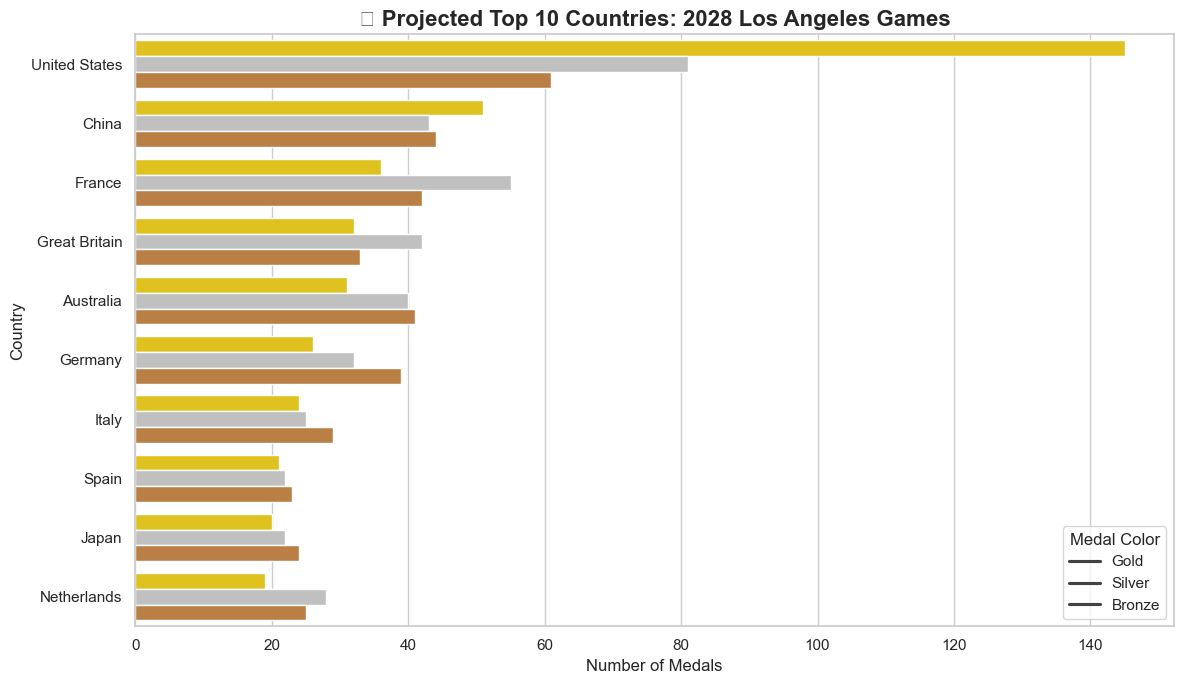

In [94]:
# Prepare the data for the Top 10
top_10_countries = country_leaderboard.head(10).copy()

# Melt the data so Seaborn can easily distinguish medal types
plot_df = top_10_countries.melt(id_vars='Team', 
                                value_vars=['Predicted_Gold', 'Predicted_Silver', 'Predicted_Bronze'],
                                var_name='Medal_Type', value_name='Count')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create a grouped bar chart
ax = sns.barplot(data=plot_df, x='Count', y='Team', hue='Medal_Type', 
                 palette={'Predicted_Gold': '#FFD700', 'Predicted_Silver': '#C0C0C0', 'Predicted_Bronze': '#CD7F32'})

plt.title('🏆 Projected Top 10 Countries: 2028 Los Angeles Games', fontsize=16, fontweight='bold')
plt.xlabel('Number of Medals', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.legend(title='Medal Color', labels=['Gold', 'Silver', 'Bronze'])
plt.tight_layout()
plt.show()

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_6336\2690628595.py:33: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
c:\Users\cjfoo\miniforge3\envs\math4025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.


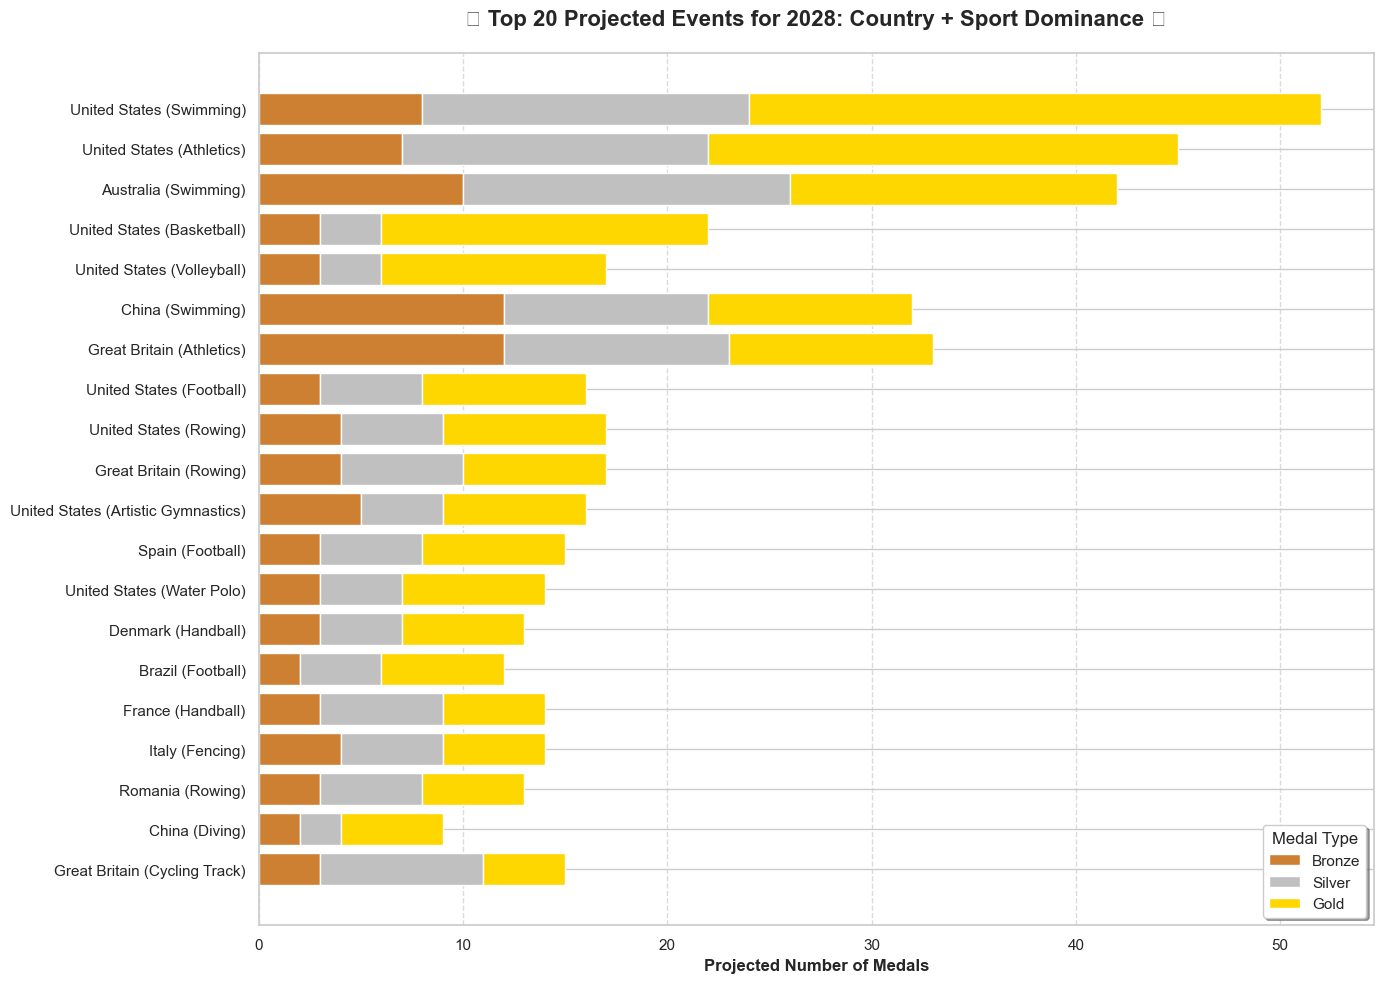

In [96]:

# 1. Prepare the Top 20 data
# We use the top_events dataframe we created in the previous step
top_20_events = top_events.head(20).copy()

# Create a clean label combining Team and Sport
top_20_events['Label'] = top_20_events['Team'] + " (" + top_20_events['Sport'] + ")"

# 2. Set up the plotting arrays
labels = top_20_events['Label'].values
gold = top_20_events['Predicted_Gold'].values
silver = top_20_events['Predicted_Silver'].values
bronze = top_20_events['Predicted_Bronze'].values
y_pos = np.arange(len(labels))

# 3. Create the stacked bar chart
plt.figure(figsize=(14, 10))

# Plot Bronze first, then stack Silver on top, then Gold on top of that
plt.barh(y_pos, bronze, color='#CD7F32', label='Bronze', edgecolor='white')
plt.barh(y_pos, silver, left=bronze, color='#C0C0C0', label='Silver', edgecolor='white')
plt.barh(y_pos, gold, left=bronze + silver, color='#FFD700', label='Gold', edgecolor='white')

# 4. Add styling and labels
plt.yticks(y_pos, labels, fontsize=11)
plt.gca().invert_yaxis()  # Highest gold count at the top
plt.xlabel('Projected Number of Medals', fontsize=12, fontweight='bold')
plt.title('🔥 Top 20 Projected Events for 2028: Country + Sport Dominance 🔥', fontsize=16, fontweight='bold', pad=20)
plt.legend(title="Medal Type", loc='lower right', frameon=True, shadow=True)

# Add gridlines for the X-axis to make it easier to read counts
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_6336\2766890981.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
c:\Users\cjfoo\miniforge3\envs\math4025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.


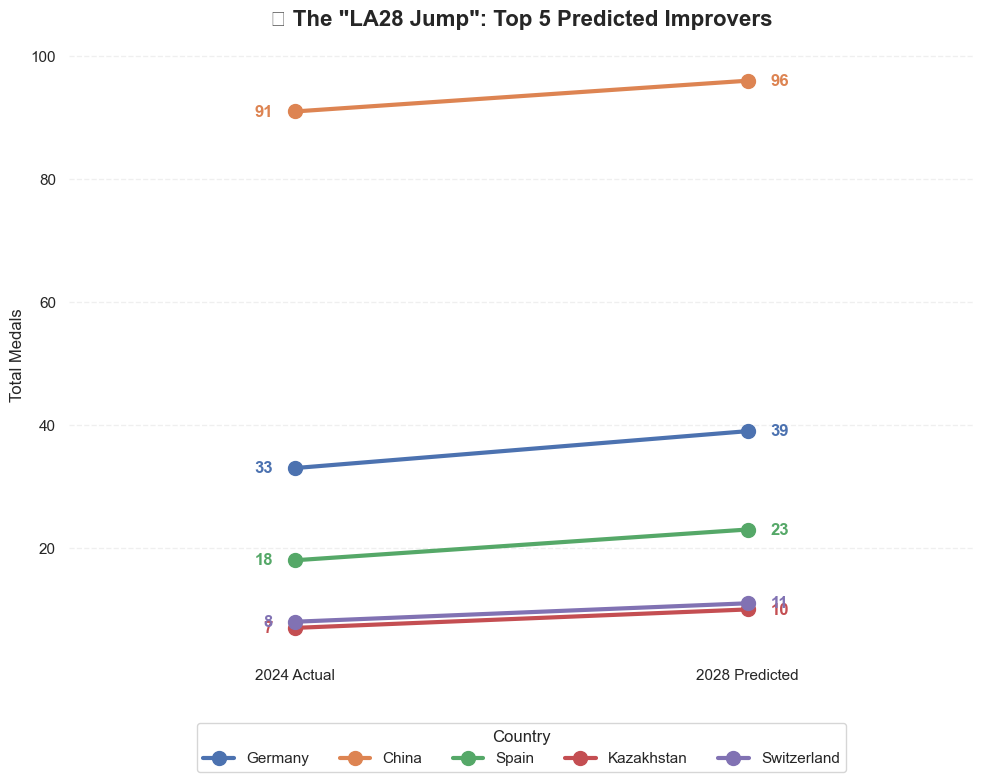

In [98]:

# 1. Calculate the 'Improvement' so we can find the biggest jumpers
# In your model, 'Lag_1_Total_Medals' is the actual 2024 count
leaderboard_2028['Improvement'] = leaderboard_2028['Predicted_Total'] - leaderboard_2028['Lag_1_Total_Medals']

# 2. Get the Top 5 countries that the model thinks will improve the most
top_improvers = leaderboard_2028.sort_values(by='Improvement', ascending=False).head(5)

# 3. Create the Slope Chart
plt.figure(figsize=(10, 8))
sns.set_style("white")

for i, row in top_improvers.iterrows():
    # x-axis points
    x_labels = ['2024 Actual', '2028 Predicted']
    # y-axis points (2024 actual vs 2028 predicted)
    y_values = [row['Lag_1_Total_Medals'], row['Predicted_Total']]
    
    # Plot the line for this country
    line = plt.plot(x_labels, y_values, marker='o', linewidth=3, markersize=10, label=row['NOC'])
    
    # Add text labels for the specific medal counts next to the points
    plt.text(-0.05, row['Lag_1_Total_Medals'], f"{int(row['Lag_1_Total_Medals'])}", 
             ha='right', va='center', fontweight='bold', color=line[0].get_color())
    plt.text(1.05, row['Predicted_Total'], f"{int(row['Predicted_Total'])}", 
             ha='left', va='center', fontweight='bold', color=line[0].get_color())

# 4. Polish the chart
plt.title('📈 The "LA28 Jump": Top 5 Predicted Improvers', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Total Medals', fontsize=12)
plt.xlim(-0.5, 1.5)  # Add breathing room for the text labels
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Country", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()